# DSAI4205 – Big Data Analytics: Text Classification Project
## Daily Public Opinion on Israel-Palestine War (Reddit Comments)

**Dataset:** Reddit comments with sentiment labels (0=Neutral, 1=Positive, 2=Negative)  
**Objective:** Build a decision support system for text classification

---

## 1. Environment Setup & Package Installation

In [1]:
# ============================================================
# 1. Install required packages (Local GPU Setup - RTX 4070)
# ============================================================
# Step 1: Install PyTorch with CUDA 12.4 support (for RTX 4070)
# Run this ONCE in your terminal/Anaconda prompt before launching Jupyter:
#   pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124
#
# Step 2: Install remaining packages
!pip install pandas numpy matplotlib seaborn scikit-learn -q
!pip install nltk wordcloud gensim xgboost lightgbm -q
!pip install transformers sentencepiece -q
!pip install imbalanced-learn -q

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from collections import Counter

# NLP
import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Sklearn
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, classification_report, confusion_matrix,
                             ConfusionMatrixDisplay)
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight

# Word cloud
from wordcloud import WordCloud

# ============================================================
# Verify GPU Setup (RTX 4070)
# ============================================================
import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA version: {torch.version.cuda}")
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
    # Enable TF32 for faster computation on RTX 4070 (Ampere+)
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    print("TF32 acceleration: Enabled")
else:
    print("⚠️ WARNING: CUDA not detected! Check your PyTorch installation.")
    print("Run: pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu124")

print("\nAll packages imported successfully!")


PyTorch version: 2.6.0+cu124
CUDA available: True
CUDA version: 12.4
GPU: NVIDIA GeForce RTX 4070 Laptop GPU
GPU Memory: 8.0 GB
TF32 acceleration: Enabled

All packages imported successfully!


In [2]:
# ============================================================
# Local File Path Setup (replace Google Colab drive mount)
# ============================================================
import os

# Set your local project directory here:
PROJECT_DIR = os.getcwd()  # Uses current directory, or set a custom path:
# PROJECT_DIR = r"C:\Users\YourName\Documents\DSAI4205_Project"
# PROJECT_DIR = "/home/yourname/DSAI4205_Project"

DATA_FILE = os.path.join(PROJECT_DIR, r"C:\Users\kktun\Desktop\Polyu year 4 Sem2\DSAI4205 Big Data Analytics\group project\Data 4 - Daily_Public_Opinion_on_Israel\reddit_opinion_PSE_ISR.csv")

# Verify file exists
if os.path.exists(DATA_FILE):
    print(f"✅ Dataset found: {DATA_FILE}")
    print(f"   File size: {os.path.getsize(DATA_FILE) / 1024:.1f} KB")
else:
    print(f"❌ Dataset NOT found at: {DATA_FILE}")
    print(f"   Please place 'reddit_opinion_PSE_ISR.csv' in: {PROJECT_DIR}")
    print(f"   Or update PROJECT_DIR above to point to your data folder.")


✅ Dataset found: C:\Users\kktun\Desktop\Polyu year 4 Sem2\DSAI4205 Big Data Analytics\group project\Data 4 - Daily_Public_Opinion_on_Israel\reddit_opinion_PSE_ISR.csv
   File size: 735.5 KB


---
## 2. Data Loading

Load the Reddit opinion dataset and inspect its structure.

In [3]:
# ============================================================
# 2. Load Dataset
# ============================================================
df = pd.read_csv(DATA_FILE)

print("Dataset Shape:", df.shape)
print("\nColumn Names:", df.columns.tolist())
print("\nData Types:")
print(df.dtypes)
print("\nFirst 5 rows:")
df.head()


Dataset Shape: (3125, 2)

Column Names: ['self_text', 'sentiment_label']

Data Types:
self_text            str
sentiment_label    int64
dtype: object

First 5 rows:


,self_text,sentiment_label
0,@BamiNasi here you go. Keep lying to yourself.,0
1,Still spooked by the woke Boogeyman eh?,0
2,https://www.ynetnews.com/article/b1ewa4nza\n\n...,0
3,"3GD ""Gnuke""",0
4,"My brother in Christ, the MRI doesnâ__t have t...",0


---
## 3. Exploratory Data Analysis (EDA)

### 3.1 Basic Statistics & Data Granularity

Each row represents a single Reddit comment with an associated sentiment label:
- 0 = Neutral
- 1 = Positive  
- 2 = Negative

In [4]:
# ============================================================
# 3.1 Basic Statistics
# ============================================================
print("Dataset shape:", df.shape)
print("Basic Info:")
df.info()
print("Descriptive Statistics:")
df.describe(include='all')

Dataset shape: (3125, 2)
Basic Info:
<class 'pandas.DataFrame'>
RangeIndex: 3125 entries, 0 to 3124
Data columns (total 2 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   self_text        3125 non-null   str  
 1   sentiment_label  3125 non-null   int64
dtypes: int64(1), str(1)
memory usage: 49.0 KB
Descriptive Statistics:


,self_text,sentiment_label
count,3125,3125.000000
unique,3117,NaN
top,Victory for Palestine,NaN
freq,3,NaN
mean,NaN,0.985600
std,NaN,0.745098
min,NaN,0.000000
25%,NaN,0.000000
50%,NaN,1.000000
75%,NaN,2.000000


In [5]:
# ============================================================
# 3.2 Missing Values Analysis
# ============================================================
print("Missing values per column:")
print(df.isnull().sum())
print("Percentage of missing values:")
print((df.isnull().sum() / len(df) * 100).round(2))

# Check for empty strings
empty_strings = (df['self_text'].astype(str).str.strip() == '').sum()
print(f"Empty string entries in self_text: {empty_strings}")

Missing values per column:
self_text          0
sentiment_label    0
dtype: int64
Percentage of missing values:
self_text          0.0
sentiment_label    0.0
dtype: float64
Empty string entries in self_text: 0


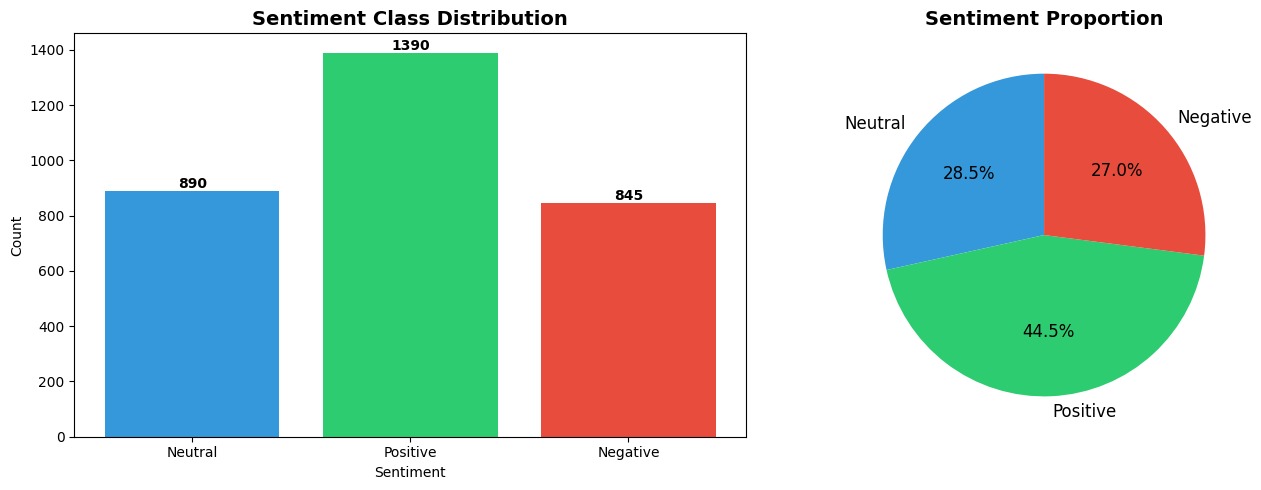

Class Distribution:
  Neutral: 890 (28.5%)
  Positive: 1390 (44.5%)
  Negative: 845 (27.0%)
⚠️ Imbalance Ratio (max/min): 1.64


In [6]:
# ============================================================
# 3.3 Class Distribution (Key: Check for Imbalance)
# ============================================================
label_map = {0: 'Neutral', 1: 'Positive', 2: 'Negative'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
counts = df['sentiment_label'].value_counts().sort_index()
colors = ['#3498db', '#2ecc71', '#e74c3c']
bars = axes[0].bar([label_map[i] for i in counts.index], counts.values, color=colors)
axes[0].set_title('Sentiment Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 10,
                 str(val), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=[label_map[i] for i in counts.index],
            autopct='%1.1f%%', colors=colors, startangle=90,
            textprops={'fontsize': 12})
axes[1].set_title('Sentiment Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Class Distribution:")
for idx, count in counts.items():
    print(f"  {label_map[idx]}: {count} ({count/len(df)*100:.1f}%)")
print(f"⚠️ Imbalance Ratio (max/min): {counts.max()/counts.min():.2f}")

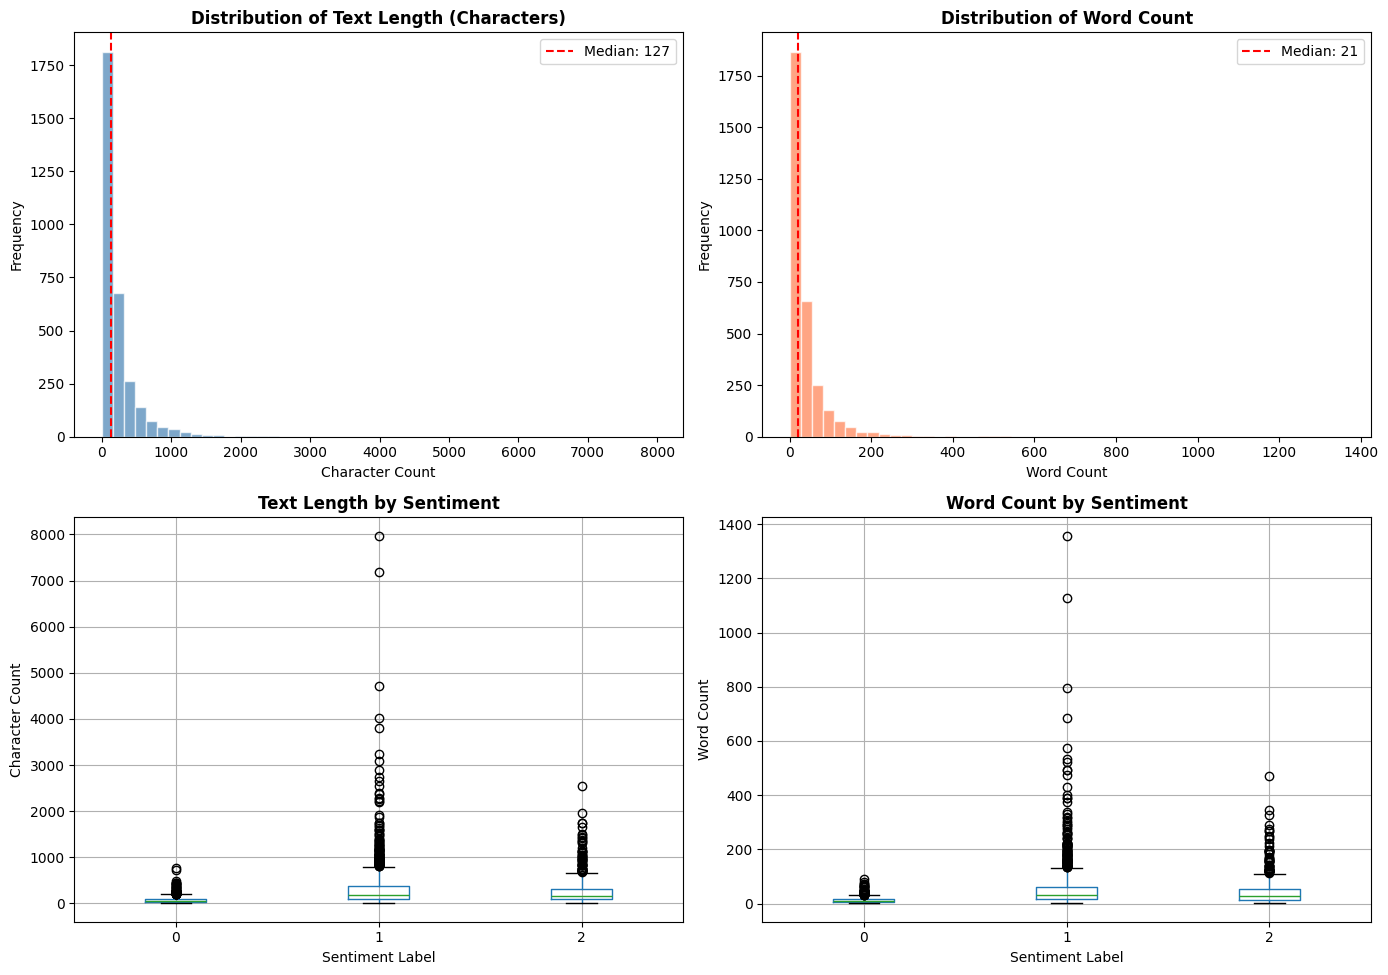

Text Length Statistics:
                text_length                                                 \
                      count   mean    std  min   25%    50%    75%     max   
sentiment_label                                                              
0                     890.0   77.3   75.8  1.0  30.0   58.0   96.8   757.0   
1                    1390.0  326.6  492.8  3.0  94.0  185.0  375.8  7973.0   
2                     845.0  250.2  270.4  6.0  87.0  166.0  316.0  2547.0   

                word_count                                             
                     count  mean   std  min   25%   50%   75%     max  
sentiment_label                                                        
0                    890.0  12.5  11.5  1.0   5.0   9.0  16.0    89.0  
1                   1390.0  55.0  82.0  1.0  16.0  31.5  63.0  1357.0  
2                    845.0  42.3  46.1  1.0  15.0  29.0  53.0   469.0  


In [7]:
# ============================================================
# 3.4 Text Length Analysis
# ============================================================
df['text_length'] = df['self_text'].astype(str).str.len()
df['word_count'] = df['self_text'].astype(str).str.split().str.len()

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Text length distribution
axes[0, 0].hist(df['text_length'], bins=50, color='steelblue', edgecolor='white', alpha=0.7)
axes[0, 0].set_title('Distribution of Text Length (Characters)', fontweight='bold')
axes[0, 0].set_xlabel('Character Count')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].axvline(df['text_length'].median(), color='red', linestyle='--', label=f'Median: {df["text_length"].median():.0f}')
axes[0, 0].legend()

# Word count distribution
axes[0, 1].hist(df['word_count'], bins=50, color='coral', edgecolor='white', alpha=0.7)
axes[0, 1].set_title('Distribution of Word Count', fontweight='bold')
axes[0, 1].set_xlabel('Word Count')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].axvline(df['word_count'].median(), color='red', linestyle='--', label=f'Median: {df["word_count"].median():.0f}')
axes[0, 1].legend()

# Text length by sentiment (boxplot)
df.boxplot(column='text_length', by='sentiment_label', ax=axes[1, 0])
axes[1, 0].set_title('Text Length by Sentiment', fontweight='bold')
axes[1, 0].set_xlabel('Sentiment Label')
axes[1, 0].set_ylabel('Character Count')
plt.suptitle('')

# Word count by sentiment (boxplot)
df.boxplot(column='word_count', by='sentiment_label', ax=axes[1, 1])
axes[1, 1].set_title('Word Count by Sentiment', fontweight='bold')
axes[1, 1].set_xlabel('Sentiment Label')
axes[1, 1].set_ylabel('Word Count')
plt.suptitle('')

plt.tight_layout()
plt.savefig('text_length_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("Text Length Statistics:")
print(df.groupby('sentiment_label')[['text_length', 'word_count']].describe().round(1))

In [8]:
# ============================================================
# 3.5 Outlier Detection (Text Length)
# ============================================================
Q1 = df['text_length'].quantile(0.25)
Q3 = df['text_length'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = df[(df['text_length'] < lower_bound) | (df['text_length'] > upper_bound)]
print(f"Text length IQR: {IQR:.0f}")
print(f"Outlier bounds: [{lower_bound:.0f}, {upper_bound:.0f}]")
print(f"Number of outliers: {len(outliers)} ({len(outliers)/len(df)*100:.1f}%)")
print(f"Outlier examples (very long texts):")
print(outliers.nlargest(3, 'text_length')[['self_text', 'text_length', 'sentiment_label']])

Text length IQR: 207
Outlier bounds: [-250, 578]
Number of outliers: 277 (8.9%)
Outlier examples (very long texts):
                                              self_text  text_length  \
1086  PART 2\n\nTo recap, we start off with UN resol...         7973   
1288  Whenever Israel has been kind the Palestinians...         7184   
1242  [here](https://www.calcalist.co.il/calcalistec...         4722   

      sentiment_label  
1086                1  
1288                1  
1242                1  


In [9]:
# ============================================================
# 3.6 Duplicate Detection
# ============================================================
duplicates = df.duplicated(subset='self_text', keep=False)
n_dup = duplicates.sum()
print(f"Number of duplicate text entries: {n_dup}")
print(f"Unique duplicate groups: {df[duplicates].groupby('self_text').ngroups}")
if n_dup > 0:
    print("Sample duplicates:")
    print(df[duplicates].sort_values('self_text').head(6))

Number of duplicate text entries: 15
Unique duplicate groups: 7
Sample duplicates:
                                              self_text  sentiment_label  \
2777  **No Zionist Propaganda/Hasbara: It is inappro...                2   
2808  **No Zionist Propaganda/Hasbara: It is inappro...                2   
404                                             Agreed.                0   
464                                             Agreed.                0   
543                                             Source?                0   
812                                             Source?                0   

      text_length  word_count  
2777          204          20  
2808          204          20  
404             7           1  
464             7           1  
543             7           1  
812             7           1  


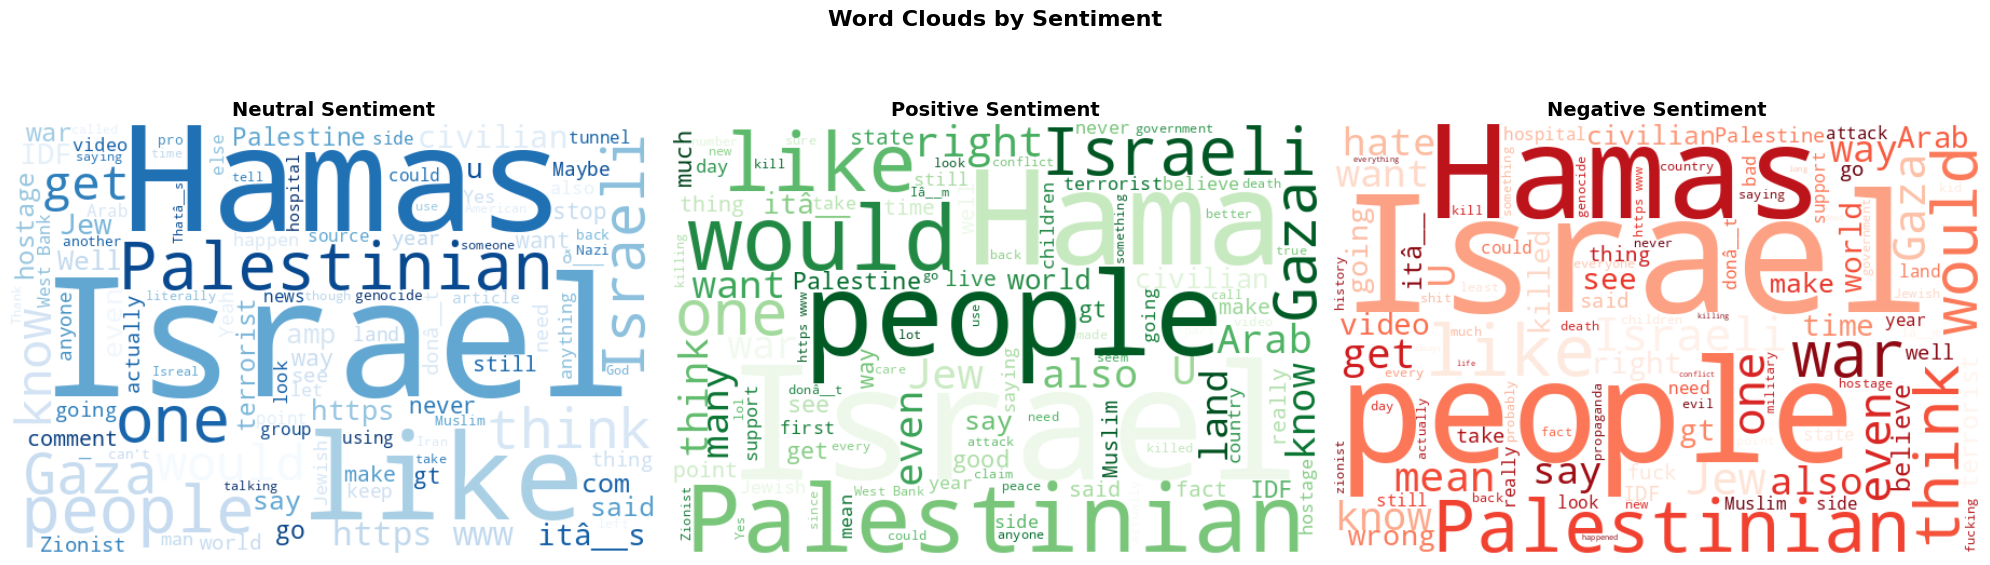

In [10]:
# ============================================================
# 3.7 Word Cloud per Sentiment
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
sentiments = {0: 'Neutral', 1: 'Positive', 2: 'Negative'}
colors_wc = ['Blues', 'Greens', 'Reds']

for i, (label, name) in enumerate(sentiments.items()):
    text = ' '.join(df[df['sentiment_label'] == label]['self_text'].astype(str).tolist())
    wc = WordCloud(width=600, height=400, background_color='white',
                   colormap=colors_wc[i], max_words=100,
                   stopwords=set(stopwords.words('english'))).generate(text)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f'{name} Sentiment', fontsize=14, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Word Clouds by Sentiment', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

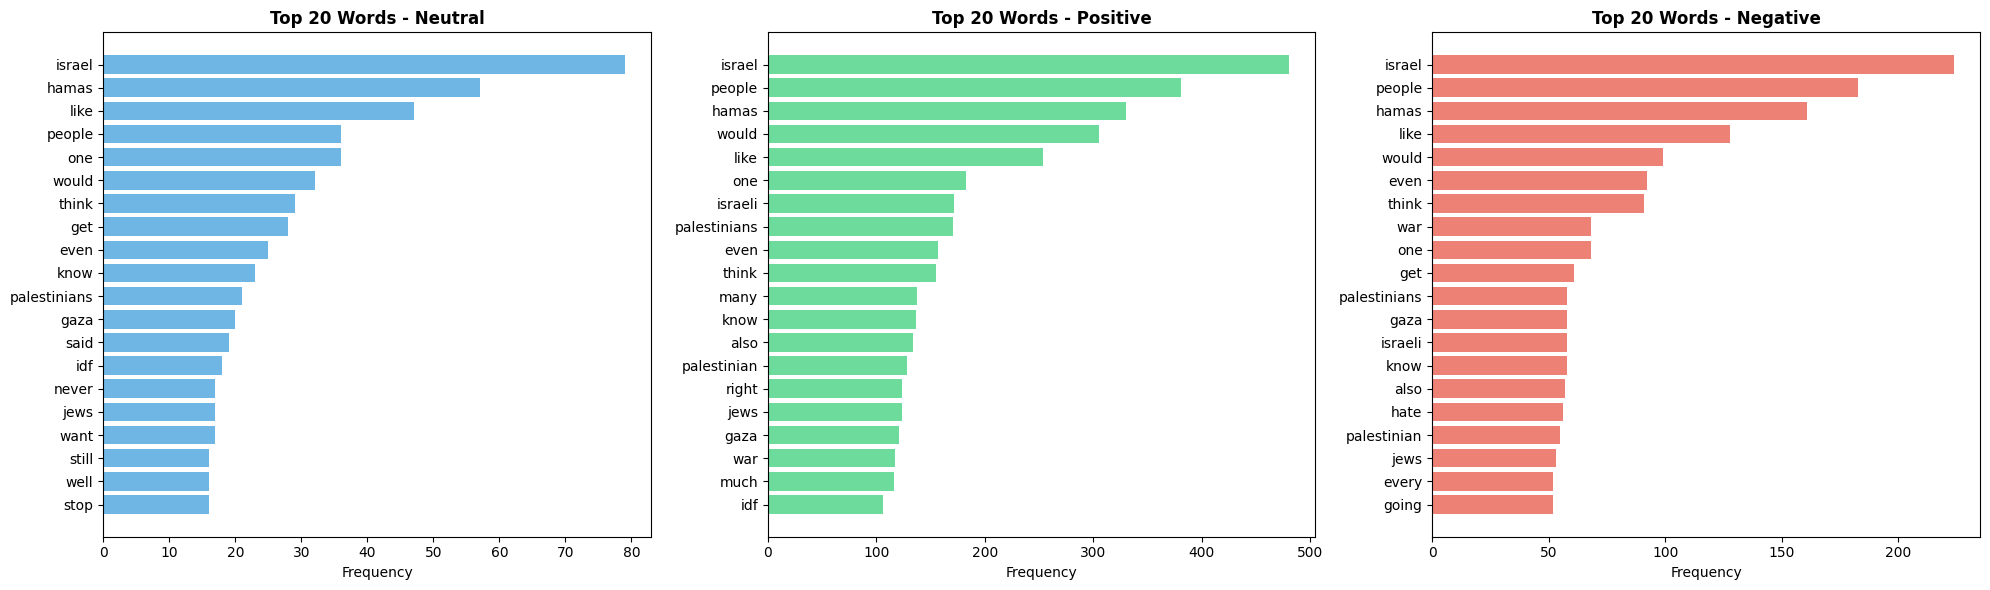

In [11]:
# ============================================================
# 3.8 Top Words per Sentiment
# ============================================================
stop_words = set(stopwords.words('english'))

def get_top_words(texts, n=20):
    words = []
    for text in texts:
        tokens = str(text).lower().split()
        tokens = [w for w in tokens if w.isalpha() and w not in stop_words and len(w) > 2]
        words.extend(tokens)
    return Counter(words).most_common(n)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for i, (label, name) in enumerate(sentiments.items()):
    top = get_top_words(df[df['sentiment_label'] == label]['self_text'])
    words, counts = zip(*top)
    axes[i].barh(range(len(words)), counts, color=colors[i], alpha=0.7)
    axes[i].set_yticks(range(len(words)))
    axes[i].set_yticklabels(words)
    axes[i].invert_yaxis()
    axes[i].set_title(f'Top 20 Words - {name}', fontweight='bold')
    axes[i].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('top_words.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 4. Data Cleaning

### Cleaning Pipeline:
1. Remove duplicates
2. Handle missing/empty values
3. Text normalization (lowercase, punctuation, URLs, mentions)
4. Tokenization & Lemmatization
5. Stopword removal
6. Document all changes

In [12]:
# ============================================================
# 4. Data Cleaning Pipeline
# ============================================================
print(f"Original dataset size: {len(df)}")
cleaning_log = []

# --- 4.1 Remove Duplicates ---
before = len(df)
df = df.drop_duplicates(subset='self_text', keep='first').reset_index(drop=True)
after = len(df)
msg = f"Removed {before - after} duplicate rows"
cleaning_log.append(msg)
print(msg)

# --- 4.2 Remove empty/very short texts ---
before = len(df)
df['self_text'] = df['self_text'].astype(str).str.strip()
df = df[df['self_text'].str.len() > 2].reset_index(drop=True)
after = len(df)
msg = f"Removed {before - after} empty/very short entries"
cleaning_log.append(msg)
print(msg)

# --- 4.3 Text Preprocessing Function ---
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def clean_text(text):
    """Comprehensive text cleaning pipeline"""
    text = str(text)
    # Remove URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    # Remove Reddit-specific patterns
    text = re.sub(r'/r/\w+', '', text)  # subreddit mentions
    text = re.sub(r'/u/\w+', '', text)  # user mentions
    text = re.sub(r'u/\w+', '', text)
    # Remove HTML entities
    text = re.sub(r'&\w+;', '', text)
    # Remove special characters and numbers (keep apostrophes for contractions)
    text = re.sub(r"[^a-zA-Z\s']", " ", text)
    # Lowercase
    text = text.lower()
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def preprocess_text(text):
    """Tokenize, lemmatize, remove stopwords"""
    text = clean_text(text)
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(w) for w in tokens
              if w not in stop_words and len(w) > 2 and w.isalpha()]
    return ' '.join(tokens)

# Apply cleaning
df['cleaned_text'] = df['self_text'].apply(clean_text)
df['processed_text'] = df['self_text'].apply(preprocess_text)

msg = "Applied text cleaning: URL removal, lowercasing, punctuation removal, lemmatization, stopword removal"
cleaning_log.append(msg)
print(msg)

# --- 4.4 Remove entries that become empty after cleaning ---
before = len(df)
df = df[df['processed_text'].str.strip().str.len() > 0].reset_index(drop=True)
after = len(df)
msg = f"Removed {before - after} entries that became empty after cleaning"
cleaning_log.append(msg)
print(msg)

print(f"Final dataset size: {len(df)}")
print(f"=== Cleaning Log ===")
for i, log in enumerate(cleaning_log, 1):
    print(f"  {i}. {log}")

# Show before/after examples
print("=== Sample Before/After Cleaning ===")
for i in range(min(3, len(df))):
    print(f"Original:  {df.iloc[i]['self_text'][:100]}...")
    print(f"Cleaned:   {df.iloc[i]['cleaned_text'][:100]}...")
    print(f"Processed: {df.iloc[i]['processed_text'][:100]}...")

Original dataset size: 3125
Removed 8 duplicate rows
Removed 1 empty/very short entries
Applied text cleaning: URL removal, lowercasing, punctuation removal, lemmatization, stopword removal
Removed 39 entries that became empty after cleaning
Final dataset size: 3077
=== Cleaning Log ===
  1. Removed 8 duplicate rows
  2. Removed 1 empty/very short entries
  3. Applied text cleaning: URL removal, lowercasing, punctuation removal, lemmatization, stopword removal
  4. Removed 39 entries that became empty after cleaning
=== Sample Before/After Cleaning ===
Original:  @BamiNasi here you go. Keep lying to yourself....
Cleaned:   baminasi here you go keep lying to yourself...
Processed: baminasi keep lying...
Original:  Still spooked by the woke Boogeyman eh?...
Cleaned:   still spooked by the woke boogeyman eh...
Processed: still spooked woke boogeyman...
Original:  https://www.ynetnews.com/article/b1ewa4nza

There was a reason why your Iron Dome was turned off on ...
Cleaned:   there was a 

---
## 5. Train-Test Split

In [13]:
# ============================================================
# 5. Train-Test Split (Stratified)
# ============================================================
X = df['processed_text']
y = df['sentiment_label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {len(X_train)} samples")
print(f"Test set:     {len(X_test)} samples")
print(f"Training label distribution:")
print(y_train.value_counts().sort_index())
print(f"Test label distribution:")
print(y_test.value_counts().sort_index())

Training set: 2461 samples
Test set:     616 samples
Training label distribution:
sentiment_label
0     676
1    1111
2     674
Name: count, dtype: int64
Test label distribution:
sentiment_label
0    169
1    278
2    169
Name: count, dtype: int64


---
## 6. Phase 3(i): Baseline Model – Logistic Regression with TF-IDF

TF-IDF Feature Matrix Shape: (2461, 6463)
BASELINE MODEL: Logistic Regression + TF-IDF
Accuracy:  0.6623
Precision: 0.6629
Recall:    0.6623
F1-Score:  0.6617
Classification Report:
              precision    recall  f1-score   support

     Neutral       0.62      0.69      0.66       169
    Positive       0.71      0.70      0.71       278
    Negative       0.63      0.57      0.60       169

    accuracy                           0.66       616
   macro avg       0.65      0.65      0.65       616
weighted avg       0.66      0.66      0.66       616



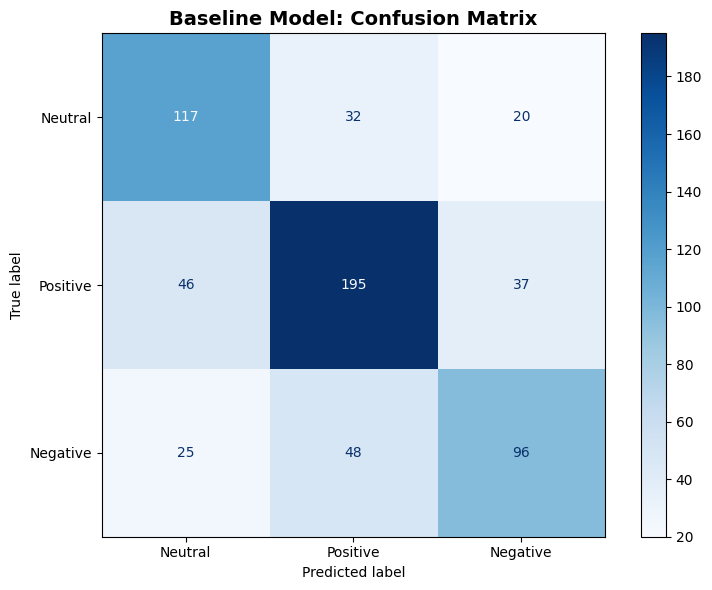

In [14]:
# ============================================================
# 6. Baseline: Logistic Regression + TF-IDF
# ============================================================
# TF-IDF Vectorization
tfidf = TfidfVectorizer(max_features=10000, ngram_range=(1, 2),
                         min_df=2, max_df=0.95, sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"TF-IDF Feature Matrix Shape: {X_train_tfidf.shape}")

# Logistic Regression (baseline)
baseline_model = LogisticRegression(max_iter=1000, random_state=42,class_weight='balanced', C=1.0)
baseline_model.fit(X_train_tfidf, y_train)

# Predictions
y_pred_baseline = baseline_model.predict(X_test_tfidf)

# Evaluation
print("" + "="*60)
print("BASELINE MODEL: Logistic Regression + TF-IDF")
print("="*60)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_baseline):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_baseline, average='weighted'):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred_baseline, average='weighted'):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_baseline, average='weighted'):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_baseline,target_names=['Neutral', 'Positive', 'Negative']))

# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_baseline)
disp = ConfusionMatrixDisplay(cm, display_labels=['Neutral', 'Positive', 'Negative'])
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title('Baseline Model: Confusion Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('baseline_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 7. Phase 3(ii): Advanced Models with Word Embeddings

### Strategy: Combine word embedding models with analytics classifiers

| Model # | Embedding Model | Analytics Classifier |
|---------|----------------|---------------------|
| 1 | Word2Vec | XGBoost |
| 2 | GloVe | LightGBM |
| 3 | BERT | Random Forest |
| 4 | BERT | Neural Network (MLP) |
| 5 | BERT | SVM |

**High-level approach:**
1. Generate document embeddings from word embedding models
2. Use these embeddings as feature vectors for the analytics classifiers
3. For Word2Vec/GloVe: average word vectors to get document-level embeddings
4. For BERT: use [CLS] token output as document embedding

### 7.1 Word2Vec Embeddings + XGBoost

In [15]:
# ============================================================
# 7.1 Word2Vec + XGBoost
# ============================================================
from gensim.models import Word2Vec
import xgboost as xgb

# Tokenize for Word2Vec
train_tokens = [text.split() for text in X_train]
test_tokens = [text.split() for text in X_test]

# Train Word2Vec model from scratch
w2v_model = Word2Vec(sentences=train_tokens, vector_size=200, window=5,
                      min_count=2, workers=4, epochs=30, sg=1)  # sg=1 for skip-gram

print(f"Word2Vec vocabulary size: {len(w2v_model.wv)}")
print(f"Embedding dimension: {w2v_model.wv.vector_size}")

def get_doc_embedding(tokens, model, dim=200):
    """Average word vectors to get document embedding"""
    vectors = [model.wv[w] for w in tokens if w in model.wv]
    if len(vectors) == 0:
        return np.zeros(dim)
    return np.mean(vectors, axis=0)

# Generate document embeddings
X_train_w2v = np.array([get_doc_embedding(t, w2v_model) for t in train_tokens])
X_test_w2v = np.array([get_doc_embedding(t, w2v_model) for t in test_tokens])

print(f"W2V Train embedding shape: {X_train_w2v.shape}")
print(f"W2V Test embedding shape: {X_test_w2v.shape}")

# XGBoost Classifier
xgb_model = xgb.XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    objective='multi:softmax', num_class=3,
    eval_metric='mlogloss', random_state=42,
    use_label_encoder=False
)
xgb_model.fit(X_train_w2v, y_train)
y_pred_xgb = xgb_model.predict(X_test_w2v)

print("" + "="*60)
print("MODEL 1: Word2Vec + XGBoost")
print("="*60)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_xgb, average='weighted'):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_xgb,target_names=['Neutral', 'Positive', 'Negative']))

Word2Vec vocabulary size: 3968
Embedding dimension: 200
W2V Train embedding shape: (2461, 200)
W2V Test embedding shape: (616, 200)
MODEL 1: Word2Vec + XGBoost
Accuracy:  0.5617
F1-Score:  0.5433
Classification Report:
              precision    recall  f1-score   support

     Neutral       0.71      0.42      0.53       169
    Positive       0.56      0.79      0.66       278
    Negative       0.45      0.32      0.37       169

    accuracy                           0.56       616
   macro avg       0.57      0.51      0.52       616
weighted avg       0.57      0.56      0.54       616



### 7.2 GloVe Embeddings + LightGBM

In [16]:
# ============================================================
# 7.2 GloVe + LightGBM
# ============================================================
import lightgbm as lgb

# Load pre-trained GloVe embeddings
# Download GloVe: https://nlp.stanford.edu/data/glove.6B.zip
# Extract glove.6B.200d.txt to your working directory

def load_glove(filepath, dim=200):
    """Load GloVe embeddings from file"""
    embeddings = {}
    with open(filepath, 'r', encoding='utf-8') as f:
        for line in f:
            values = line.strip().split()
            word = values[0]
            vector = np.array(values[1:], dtype='float32')
            if len(vector) == dim:
                embeddings[word] = vector
    return embeddings

# NOTE: Download GloVe embeddings first. Uncomment and set path:
# glove_path = 'glove.6B.200d.txt'
# glove_embeddings = load_glove(glove_path, dim=200)

# Alternative: Use Word2Vec as a stand-in if GloVe file is not available
# For demonstration, we'll train a CBOW model (similar to GloVe conceptually)
glove_like_model = Word2Vec(sentences=train_tokens, vector_size=200, window=10,
                             min_count=2, workers=4, epochs=30, sg=0)  # sg=0 = CBOW

def get_glove_doc_embedding(tokens, model, dim=200):
    """Get document embedding using GloVe/CBOW vectors"""
    vectors = [model.wv[w] for w in tokens if w in model.wv]
    if len(vectors) == 0:
        return np.zeros(dim)
    return np.mean(vectors, axis=0)

X_train_glove = np.array([get_glove_doc_embedding(t, glove_like_model) for t in train_tokens])
X_test_glove = np.array([get_glove_doc_embedding(t, glove_like_model) for t in test_tokens])

# LightGBM Classifier
lgb_model = lgb.LGBMClassifier(
    n_estimators=200, max_depth=8, learning_rate=0.1,
    num_leaves=31, objective='multiclass', num_class=3,
    class_weight='balanced', random_state=42, verbose=-1
)
lgb_model.fit(X_train_glove, y_train)
y_pred_lgb = lgb_model.predict(X_test_glove)

print("" + "="*60)
print("MODEL 2: GloVe (CBOW) + LightGBM")
print("="*60)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_lgb):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_lgb, average='weighted'):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_lgb,
                           target_names=['Neutral', 'Positive', 'Negative']))

MODEL 2: GloVe (CBOW) + LightGBM
Accuracy:  0.5195
F1-Score:  0.5107
Classification Report:
              precision    recall  f1-score   support

     Neutral       0.59      0.47      0.52       169
    Positive       0.56      0.68      0.61       278
    Negative       0.37      0.31      0.34       169

    accuracy                           0.52       616
   macro avg       0.50      0.49      0.49       616
weighted avg       0.51      0.52      0.51       616



### 7.3 BERT Embeddings + Random Forest

In [17]:
# ============================================================
# 7.3 BERT Embeddings + Random Forest (GPU-Optimized for RTX 4070)
# ============================================================
import torch
from transformers import BertTokenizer, BertModel
from sklearn.ensemble import RandomForestClassifier

# Load pre-trained BERT on GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    torch.cuda.empty_cache()  # Clear any residual GPU memory

tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
bert_model = BertModel.from_pretrained('bert-base-uncased').to(device)
bert_model.eval()

# Enable mixed precision for faster inference on RTX 4070
use_amp = device.type == 'cuda'

def get_bert_embeddings(texts, tokenizer, model, device, batch_size=64, max_length=128):
    """Extract BERT [CLS] token embeddings - GPU optimized with AMP"""
    all_embeddings = []
    total = len(texts)
    for i in range(0, total, batch_size):
        batch = texts[i:i+batch_size]
        encoded = tokenizer(batch, padding=True, truncation=True,
                           max_length=max_length, return_tensors='pt').to(device)
        with torch.no_grad():
            if use_amp:
                with torch.amp.autocast('cuda'):
                    outputs = model(**encoded)
            else:
                outputs = model(**encoded)
        cls_embeddings = outputs.last_hidden_state[:, 0, :].float().cpu().numpy()
        all_embeddings.append(cls_embeddings)
        if (i // batch_size) % 5 == 0:
            print(f"  Processed {min(i+batch_size, total)}/{total} texts...")
    return np.vstack(all_embeddings)

print("Extracting BERT embeddings for training set...")
X_train_bert = get_bert_embeddings(X_train.tolist(), tokenizer, bert_model, device)
print("Extracting BERT embeddings for test set...")
X_test_bert = get_bert_embeddings(X_test.tolist(), tokenizer, bert_model, device)

print(f"\nBERT embedding shape: {X_train_bert.shape}")
if device.type == 'cuda':
    print(f"GPU Memory used: {torch.cuda.memory_allocated(0) / 1024**2:.0f} MB")

# Random Forest Classifier
rf_model = RandomForestClassifier(
    n_estimators=300, max_depth=20, min_samples_split=5,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf_model.fit(X_train_bert, y_train)
y_pred_rf = rf_model.predict(X_test_bert)

print("\n" + "="*60)
print("MODEL 3: BERT + Random Forest")
print("="*60)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_rf, average='weighted'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf,
                           target_names=['Neutral', 'Positive', 'Negative']))


Using device: cuda
GPU: NVIDIA GeForce RTX 4070 Laptop GPU


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Extracting BERT embeddings for training set...
  Processed 64/2461 texts...
  Processed 384/2461 texts...
  Processed 704/2461 texts...
  Processed 1024/2461 texts...
  Processed 1344/2461 texts...
  Processed 1664/2461 texts...
  Processed 1984/2461 texts...
  Processed 2304/2461 texts...
Extracting BERT embeddings for test set...
  Processed 64/616 texts...
  Processed 384/616 texts...

BERT embedding shape: (2461, 768)
GPU Memory used: 427 MB

MODEL 3: BERT + Random Forest
Accuracy:  0.5812
F1-Score:  0.5339

Classification Report:
              precision    recall  f1-score   support

     Neutral       0.63      0.59      0.61       169
    Positive       0.56      0.84      0.67       278
    Negative       0.63      0.14      0.23       169

    accuracy                           0.58       616
   macro avg       0.61      0.53      0.50       616
weighted avg       0.60      0.58      0.53       616



### 7.4 BERT Embeddings + Neural Network (MLP)

Epoch [5/30], Loss: 0.6243
Epoch [10/30], Loss: 0.3786
Epoch [15/30], Loss: 0.1657
Epoch [20/30], Loss: 0.1338
Epoch [25/30], Loss: 0.0709
Epoch [30/30], Loss: 0.0597

MODEL 4: BERT + Neural Network (MLP)
Accuracy:  0.5584
F1-Score:  0.5618

Classification Report:
              precision    recall  f1-score   support

     Neutral       0.62      0.55      0.58       169
    Positive       0.62      0.58      0.60       278
    Negative       0.43      0.53      0.48       169

    accuracy                           0.56       616
   macro avg       0.56      0.55      0.55       616
weighted avg       0.57      0.56      0.56       616


GPU Memory used: 455 MB


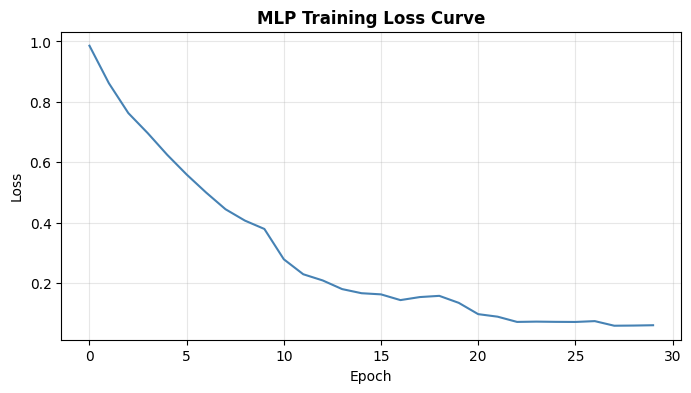

In [18]:
# ============================================================
# 7.4 BERT + Neural Network (MLP with PyTorch) - GPU Optimized
# ============================================================
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

class MLPClassifier(nn.Module):
    """Multi-Layer Perceptron for text classification"""
    def __init__(self, input_dim, hidden_dims=[512, 256, 128], num_classes=3, dropout=0.3):
        super(MLPClassifier, self).__init__()
        layers = []
        prev_dim = input_dim
        for h_dim in hidden_dims:
            layers.extend([
                nn.Linear(prev_dim, h_dim),
                nn.BatchNorm1d(h_dim),
                nn.ReLU(),
                nn.Dropout(dropout)
            ])
            prev_dim = h_dim
        layers.append(nn.Linear(prev_dim, num_classes))
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)

# Prepare data - move to GPU
X_tr_tensor = torch.FloatTensor(X_train_bert).to(device)
y_tr_tensor = torch.LongTensor(y_train.values).to(device)
X_te_tensor = torch.FloatTensor(X_test_bert).to(device)

# Use pin_memory for faster CPU→GPU transfer
train_dataset = TensorDataset(X_tr_tensor, y_tr_tensor)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# Compute class weights for loss function
class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train.values)
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

# Initialize model on GPU
mlp_model = MLPClassifier(input_dim=768, hidden_dims=[512, 256, 128],
                           num_classes=3, dropout=0.3).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(mlp_model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

# Mixed precision scaler for RTX 4070
use_amp = device.type == 'cuda'
scaler = torch.amp.GradScaler('cuda') if use_amp else None

# Training loop with AMP
n_epochs = 30
train_losses = []

for epoch in range(n_epochs):
    mlp_model.train()
    epoch_loss = 0
    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        if use_amp:
            with torch.amp.autocast('cuda'):
                outputs = mlp_model(batch_x)
                loss = criterion(outputs, batch_y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            outputs = mlp_model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
        epoch_loss += loss.item()
    scheduler.step()
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    if (epoch + 1) % 5 == 0:
        print(f"Epoch [{epoch+1}/{n_epochs}], Loss: {avg_loss:.4f}")

# Evaluate
mlp_model.eval()
with torch.no_grad():
    if use_amp:
        with torch.amp.autocast('cuda'):
            outputs = mlp_model(X_te_tensor)
    else:
        outputs = mlp_model(X_te_tensor)
    y_pred_mlp = outputs.argmax(dim=1).cpu().numpy()

print("\n" + "="*60)
print("MODEL 4: BERT + Neural Network (MLP)")
print("="*60)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_mlp):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_mlp, average='weighted'):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_mlp,
                           target_names=['Neutral', 'Positive', 'Negative']))

if device.type == 'cuda':
    print(f"\nGPU Memory used: {torch.cuda.memory_allocated(0) / 1024**2:.0f} MB")

# Plot training loss
plt.figure(figsize=(8, 4))
plt.plot(train_losses, color='steelblue')
plt.title('MLP Training Loss Curve', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True, alpha=0.3)
plt.savefig('mlp_training_loss.png', dpi=150, bbox_inches='tight')
plt.show()


### 7.5 BERT Embeddings + SVM

In [19]:
# ============================================================
# 7.5 BERT + SVM
# ============================================================
from sklearn.svm import SVC

svm_model = SVC(kernel='rbf', C=10, gamma='scale',
                class_weight='balanced', random_state=42,
                decision_function_shape='ovr')
svm_model.fit(X_train_bert, y_train)
y_pred_svm = svm_model.predict(X_test_bert)

print("" + "="*60)
print("MODEL 5: BERT + SVM")
print("="*60)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_svm):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_svm, average='weighted'):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_svm,target_names=['Neutral', 'Positive', 'Negative']))

MODEL 5: BERT + SVM
Accuracy:  0.5860
F1-Score:  0.5877
Classification Report:
              precision    recall  f1-score   support

     Neutral       0.63      0.67      0.65       169
    Positive       0.65      0.57      0.61       278
    Negative       0.47      0.53      0.50       169

    accuracy                           0.59       616
   macro avg       0.58      0.59      0.58       616
weighted avg       0.59      0.59      0.59       616



---
## 8. Phase 3(iii): Model Comparison

MODEL COMPARISON RESULTS
                  Model  Accuracy  Precision  Recall  F1-Score
  Baseline: LR + TF-IDF    0.6623     0.6629  0.6623    0.6617
     Word2Vec + XGBoost    0.5617     0.5701  0.5617    0.5433
 GloVe(CBOW) + LightGBM    0.5195     0.5126  0.5195    0.5107
   BERT + Random Forest    0.5812     0.5979  0.5812    0.5339
BERT + MLP (Neural Net)    0.5584     0.5694  0.5584    0.5618
             BERT + SVM    0.5860     0.5931  0.5860    0.5877


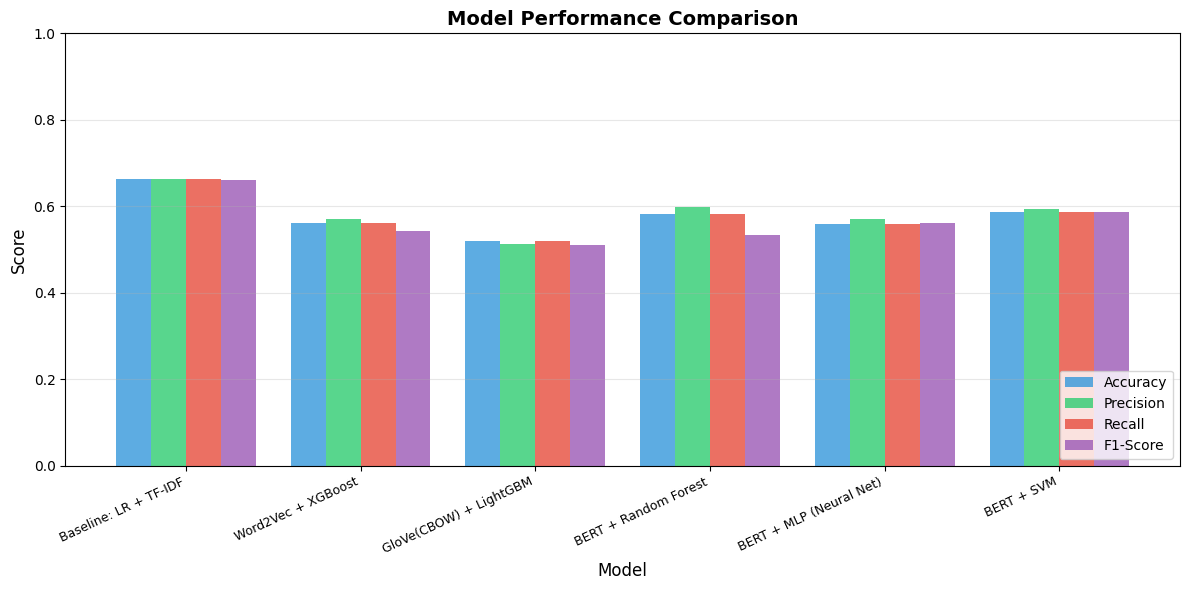

In [20]:
# ============================================================
# 8. Model Comparison Table
# ============================================================
results = {
    'Model': [
        'Baseline: LR + TF-IDF',
        'Word2Vec + XGBoost',
        'GloVe(CBOW) + LightGBM',
        'BERT + Random Forest',
        'BERT + MLP (Neural Net)',
        'BERT + SVM'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_baseline),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_lgb),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_mlp),
        accuracy_score(y_test, y_pred_svm)
    ],
    'Precision': [
        precision_score(y_test, y_pred_baseline, average='weighted'),
        precision_score(y_test, y_pred_xgb, average='weighted'),
        precision_score(y_test, y_pred_lgb, average='weighted'),
        precision_score(y_test, y_pred_rf, average='weighted'),
        precision_score(y_test, y_pred_mlp, average='weighted'),
        precision_score(y_test, y_pred_svm, average='weighted')
    ],
    'Recall': [
        recall_score(y_test, y_pred_baseline, average='weighted'),
        recall_score(y_test, y_pred_xgb, average='weighted'),
        recall_score(y_test, y_pred_lgb, average='weighted'),
        recall_score(y_test, y_pred_rf, average='weighted'),
        recall_score(y_test, y_pred_mlp, average='weighted'),
        recall_score(y_test, y_pred_svm, average='weighted')
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_baseline, average='weighted'),
        f1_score(y_test, y_pred_xgb, average='weighted'),
        f1_score(y_test, y_pred_lgb, average='weighted'),
        f1_score(y_test, y_pred_rf, average='weighted'),
        f1_score(y_test, y_pred_mlp, average='weighted'),
        f1_score(y_test, y_pred_svm, average='weighted')
    ]
}

results_df = pd.DataFrame(results)
results_df = results_df.round(4)
print("" + "="*80)
print("MODEL COMPARISON RESULTS")
print("="*80)
print(results_df.to_string(index=False))

# Visualization
fig, ax = plt.subplots(figsize=(12, 6))
x = np.arange(len(results_df))
width = 0.2
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metric_colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

for i, (metric, color) in enumerate(zip(metrics, metric_colors)):
    bars = ax.bar(x + i*width, results_df[metric], width, label=metric, color=color, alpha=0.8)

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(results_df['Model'], rotation=25, ha='right', fontsize=9)
ax.legend(loc='lower right')
ax.set_ylim(0, 1.0)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 9. Phase 3(iv): Model Refinement

### Strategies:
1. Hyperparameter tuning (GridSearchCV)
2. Handling class imbalance (SMOTE)
3. Ensemble methods (Voting Classifier)

### 9.1 Hyperparameter Tuning for Baseline (Logistic Regression + TF-IDF)

In [21]:
# ============================================================
# 9.1 Hyperparameter Tuning - Baseline LR
# ============================================================
from sklearn.model_selection import StratifiedKFold, GridSearchCV
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'max_iter': [1000]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_lr = GridSearchCV(
    LogisticRegression(class_weight='balanced', random_state=42),
    param_grid_lr, cv=cv, scoring='f1_weighted', n_jobs=-1, verbose=0
)
grid_lr.fit(X_train_tfidf, y_train)

print("Best Logistic Regression parameters:", grid_lr.best_params_)
print(f"Best CV F1-Score: {grid_lr.best_score_:.4f}")

y_pred_lr_tuned = grid_lr.best_estimator_.predict(X_test_tfidf)
print(f"Tuned Baseline Accuracy:  {accuracy_score(y_test, y_pred_lr_tuned):.4f}")
print(f"Tuned Baseline F1-Score:  {f1_score(y_test, y_pred_lr_tuned, average='weighted'):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_lr_tuned,target_names=['Neutral', 'Positive', 'Negative']))

Best Logistic Regression parameters: {'C': 10, 'max_iter': 1000, 'penalty': 'l1', 'solver': 'saga'}
Best CV F1-Score: 0.6797
Tuned Baseline Accuracy:  0.6997
Tuned Baseline F1-Score:  0.6988
Classification Report:
              precision    recall  f1-score   support

     Neutral       0.66      0.82      0.73       169
    Positive       0.77      0.67      0.72       278
    Negative       0.65      0.62      0.63       169

    accuracy                           0.70       616
   macro avg       0.69      0.71      0.69       616
weighted avg       0.71      0.70      0.70       616



### 9.2 Handling Class Imbalance with SMOTE

In [22]:
# ============================================================
# 9.2 SMOTE Oversampling
# ============================================================
from imblearn.over_sampling import SMOTE

# Apply SMOTE to TF-IDF features
smote = SMOTE(random_state=42)
X_train_tfidf_smote, y_train_smote = smote.fit_resample(X_train_tfidf, y_train)

print(f"Before SMOTE: {dict(pd.Series(y_train).value_counts().sort_index())}")
print(f"After SMOTE:  {dict(pd.Series(y_train_smote).value_counts().sort_index())}")

# Retrain baseline with SMOTE data
lr_smote = LogisticRegression(**grid_lr.best_params_, class_weight='balanced', random_state=42)
lr_smote.fit(X_train_tfidf_smote, y_train_smote)
y_pred_lr_smote = lr_smote.predict(X_test_tfidf)

print(f"Baseline + SMOTE Accuracy:  {accuracy_score(y_test, y_pred_lr_smote):.4f}")
print(f"Baseline + SMOTE F1-Score:  {f1_score(y_test, y_pred_lr_smote, average='weighted'):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_lr_smote,target_names=['Neutral', 'Positive', 'Negative']))

Before SMOTE: {0: np.int64(676), 1: np.int64(1111), 2: np.int64(674)}
After SMOTE:  {0: np.int64(1111), 1: np.int64(1111), 2: np.int64(1111)}
Baseline + SMOTE Accuracy:  0.7029
Baseline + SMOTE F1-Score:  0.7021
Classification Report:
              precision    recall  f1-score   support

     Neutral       0.67      0.82      0.73       169
    Positive       0.77      0.68      0.72       278
    Negative       0.65      0.62      0.63       169

    accuracy                           0.70       616
   macro avg       0.69      0.71      0.70       616
weighted avg       0.71      0.70      0.70       616



### 9.3 Ensemble Model (Voting Classifier)

In [23]:
# ============================================================
# 9.3 Ensemble: Voting Classifier on BERT embeddings
# ============================================================
from sklearn.ensemble import VotingClassifier

# Create ensemble of top performers using BERT embeddings
ensemble_model = VotingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=300, max_depth=20,
                                       class_weight='balanced', random_state=42)),
        ('svm', SVC(kernel='rbf', C=10, gamma='scale',
                    class_weight='balanced', probability=True, random_state=42)),
        ('xgb', xgb.XGBClassifier(n_estimators=200, max_depth=6,
                                    learning_rate=0.1, random_state=42,
                                    use_label_encoder=False, eval_metric='mlogloss'))
    ],
    voting='soft'
)
ensemble_model.fit(X_train_bert, y_train)
y_pred_ensemble = ensemble_model.predict(X_test_bert)

print("" + "="*60)
print("ENSEMBLE MODEL: BERT + Voting (RF + SVM + XGBoost)")
print("="*60)
print(f"Accuracy:  {accuracy_score(y_test, y_pred_ensemble):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred_ensemble, average='weighted'):.4f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_ensemble,target_names=['Neutral', 'Positive', 'Negative']))

ENSEMBLE MODEL: BERT + Voting (RF + SVM + XGBoost)
Accuracy:  0.6039
F1-Score:  0.5827
Classification Report:
              precision    recall  f1-score   support

     Neutral       0.62      0.59      0.61       169
    Positive       0.60      0.80      0.69       278
    Negative       0.58      0.29      0.39       169

    accuracy                           0.60       616
   macro avg       0.60      0.56      0.56       616
weighted avg       0.60      0.60      0.58       616



### 9.4 Hyperparameter Tuning for XGBoost + Word2Vec

In [24]:
# ============================================================
# 9.4 Hyperparameter Tuning - XGBoost
# ============================================================
param_grid_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    xgb.XGBClassifier(objective='multi:softmax', num_class=3,
                       eval_metric='mlogloss', random_state=42,
                       use_label_encoder=False),
    param_grid_xgb, cv=cv, scoring='f1_weighted', n_jobs=-1, verbose=0
)
grid_xgb.fit(X_train_w2v, y_train)

print("Best XGBoost parameters:", grid_xgb.best_params_)
y_pred_xgb_tuned = grid_xgb.best_estimator_.predict(X_test_w2v)
print(f"Tuned XGBoost Accuracy:  {accuracy_score(y_test, y_pred_xgb_tuned):.4f}")
print(f"Tuned XGBoost F1-Score:  {f1_score(y_test, y_pred_xgb_tuned, average='weighted'):.4f}")

Best XGBoost parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 300, 'subsample': 0.8}
Tuned XGBoost Accuracy:  0.5747
Tuned XGBoost F1-Score:  0.5562


### 9.5 Final Refined Comparison

FINAL MODEL RANKING (by F1-Score)
                                Model  Accuracy  F1-Score
Baseline: LR + TF-IDF (Tuned + SMOTE)    0.7029    0.7021
        Baseline: LR + TF-IDF (Tuned)    0.6997    0.6988
     Baseline: LR + TF-IDF (Original)    0.6623    0.6617
                           BERT + SVM    0.5860    0.5877
         BERT + Ensemble (RF+SVM+XGB)    0.6039    0.5827
              BERT + MLP (Neural Net)    0.5584    0.5618
           Word2Vec + XGBoost (Tuned)    0.5747    0.5562
        Word2Vec + XGBoost (Original)    0.5617    0.5433
                 BERT + Random Forest    0.5812    0.5339
               GloVe(CBOW) + LightGBM    0.5195    0.5107


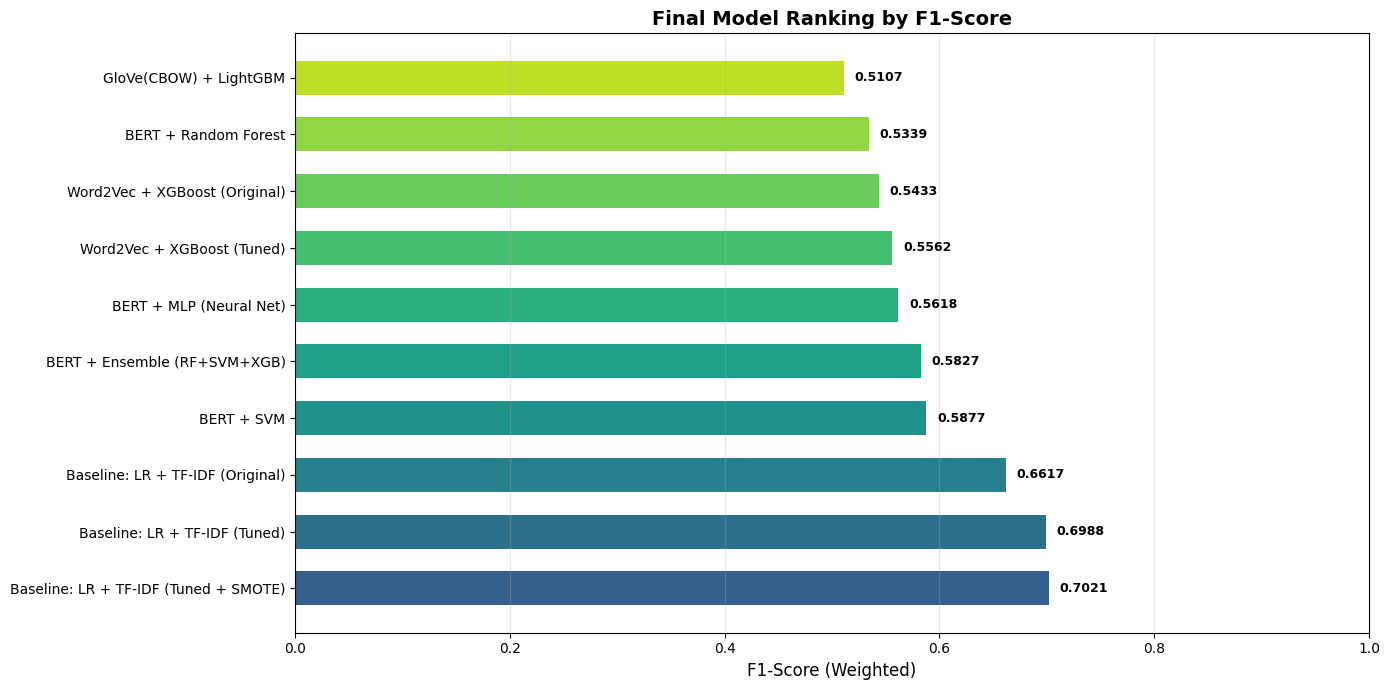

In [25]:
# ============================================================
# 9.5 Final Comparison (Original vs Refined)
# ============================================================
final_results = {
    'Model': [
        'Baseline: LR + TF-IDF (Original)',
        'Baseline: LR + TF-IDF (Tuned)',
        'Baseline: LR + TF-IDF (Tuned + SMOTE)',
        'Word2Vec + XGBoost (Original)',
        'Word2Vec + XGBoost (Tuned)',
        'GloVe(CBOW) + LightGBM',
        'BERT + Random Forest',
        'BERT + MLP (Neural Net)',
        'BERT + SVM',
        'BERT + Ensemble (RF+SVM+XGB)'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_baseline),
        accuracy_score(y_test, y_pred_lr_tuned),
        accuracy_score(y_test, y_pred_lr_smote),
        accuracy_score(y_test, y_pred_xgb),
        accuracy_score(y_test, y_pred_xgb_tuned),
        accuracy_score(y_test, y_pred_lgb),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_mlp),
        accuracy_score(y_test, y_pred_svm),
        accuracy_score(y_test, y_pred_ensemble)
    ],
    'F1-Score': [
        f1_score(y_test, y_pred_baseline, average='weighted'),
        f1_score(y_test, y_pred_lr_tuned, average='weighted'),
        f1_score(y_test, y_pred_lr_smote, average='weighted'),
        f1_score(y_test, y_pred_xgb, average='weighted'),
        f1_score(y_test, y_pred_xgb_tuned, average='weighted'),
        f1_score(y_test, y_pred_lgb, average='weighted'),
        f1_score(y_test, y_pred_rf, average='weighted'),
        f1_score(y_test, y_pred_mlp, average='weighted'),
        f1_score(y_test, y_pred_svm, average='weighted'),
        f1_score(y_test, y_pred_ensemble, average='weighted')
    ]
}

final_df = pd.DataFrame(final_results).round(4)
final_df = final_df.sort_values('F1-Score', ascending=False).reset_index(drop=True)
print("" + "="*80)
print("FINAL MODEL RANKING (by F1-Score)")
print("="*80)
print(final_df.to_string(index=False))

# Visualization
fig, ax = plt.subplots(figsize=(14, 7))
y_pos = np.arange(len(final_df))
bars = ax.barh(y_pos, final_df['F1-Score'], color=plt.cm.viridis(np.linspace(0.3, 0.9, len(final_df))), height=0.6)
ax.set_yticks(y_pos)
ax.set_yticklabels(final_df['Model'], fontsize=10)
ax.set_xlabel('F1-Score (Weighted)', fontsize=12)
ax.set_title('Final Model Ranking by F1-Score', fontsize=14, fontweight='bold')
ax.set_xlim(0, 1.0)
for bar, val in zip(bars, final_df['F1-Score']):
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('final_model_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 10. Confusion Matrices for All Models

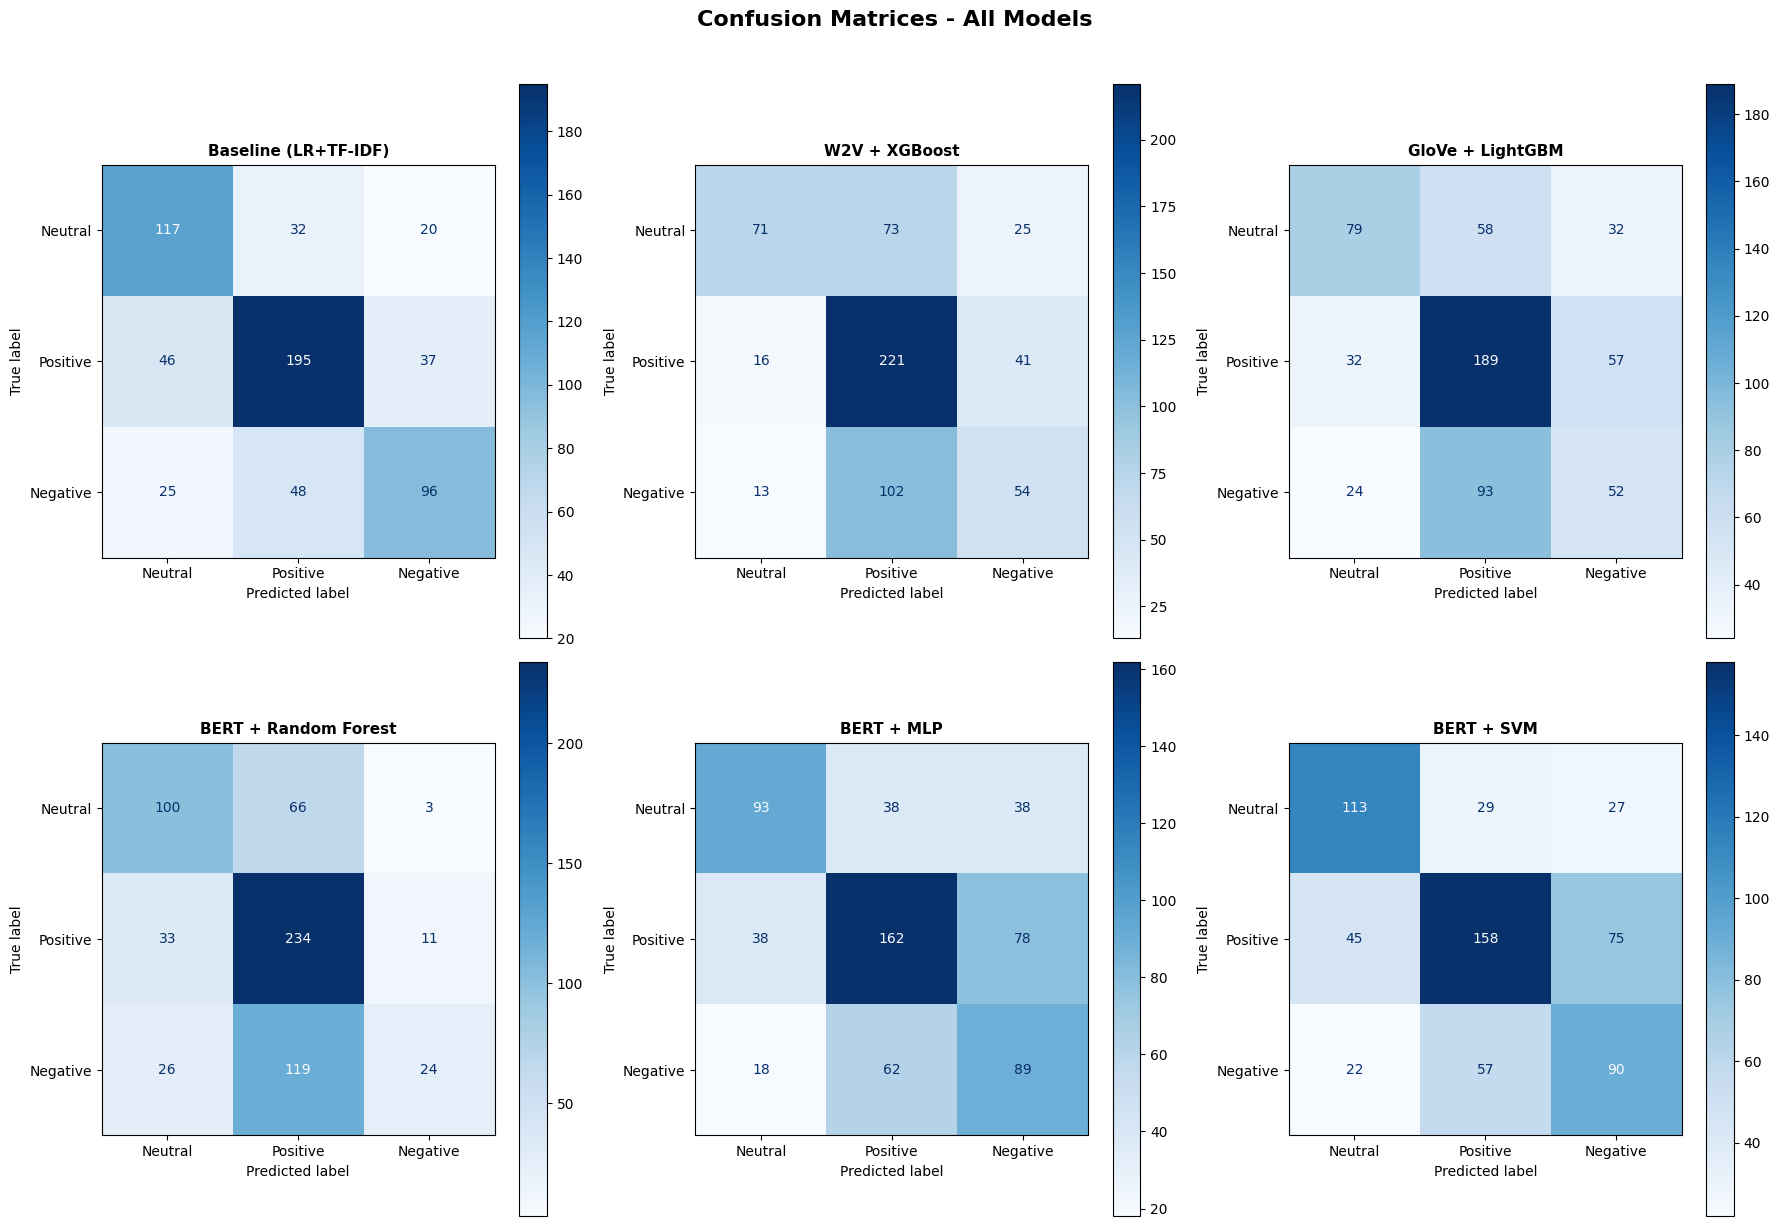

In [26]:
# ============================================================
# 10. Confusion Matrices Grid
# ============================================================
model_preds = {
    'Baseline (LR+TF-IDF)': y_pred_baseline,
    'W2V + XGBoost': y_pred_xgb,
    'GloVe + LightGBM': y_pred_lgb,
    'BERT + Random Forest': y_pred_rf,
    'BERT + MLP': y_pred_mlp,
    'BERT + SVM': y_pred_svm,
}

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for ax, (name, preds) in zip(axes, model_preds.items()):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Neutral', 'Positive', 'Negative'])
    disp.plot(ax=ax, cmap='Blues', values_format='d')
    ax.set_title(name, fontweight='bold', fontsize=11)

plt.suptitle('Confusion Matrices - All Models', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('all_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 11. Data Visualization & Storytelling

### Additional visualizations for insights and patterns

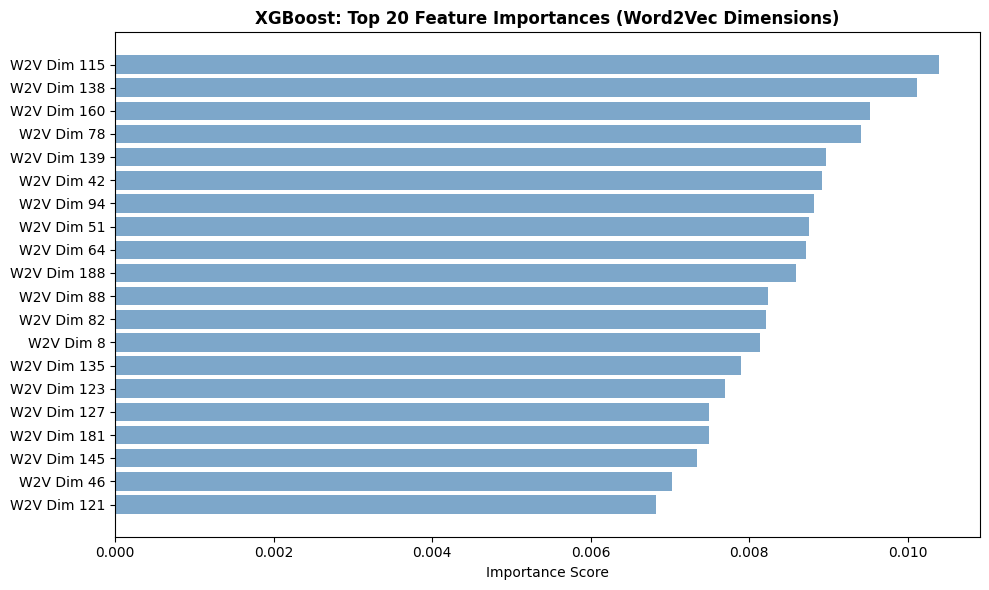

In [27]:
# ============================================================
# 11.1 Feature Importance (XGBoost)
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))
importance = xgb_model.feature_importances_
top_n = 20
top_indices = importance.argsort()[-top_n:]
ax.barh(range(top_n), importance[top_indices], color='steelblue', alpha=0.7)
ax.set_yticks(range(top_n))
ax.set_yticklabels([f'W2V Dim {i}' for i in top_indices])
ax.set_title('XGBoost: Top 20 Feature Importances (Word2Vec Dimensions)', fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance_xgb.png', dpi=150, bbox_inches='tight')
plt.show()

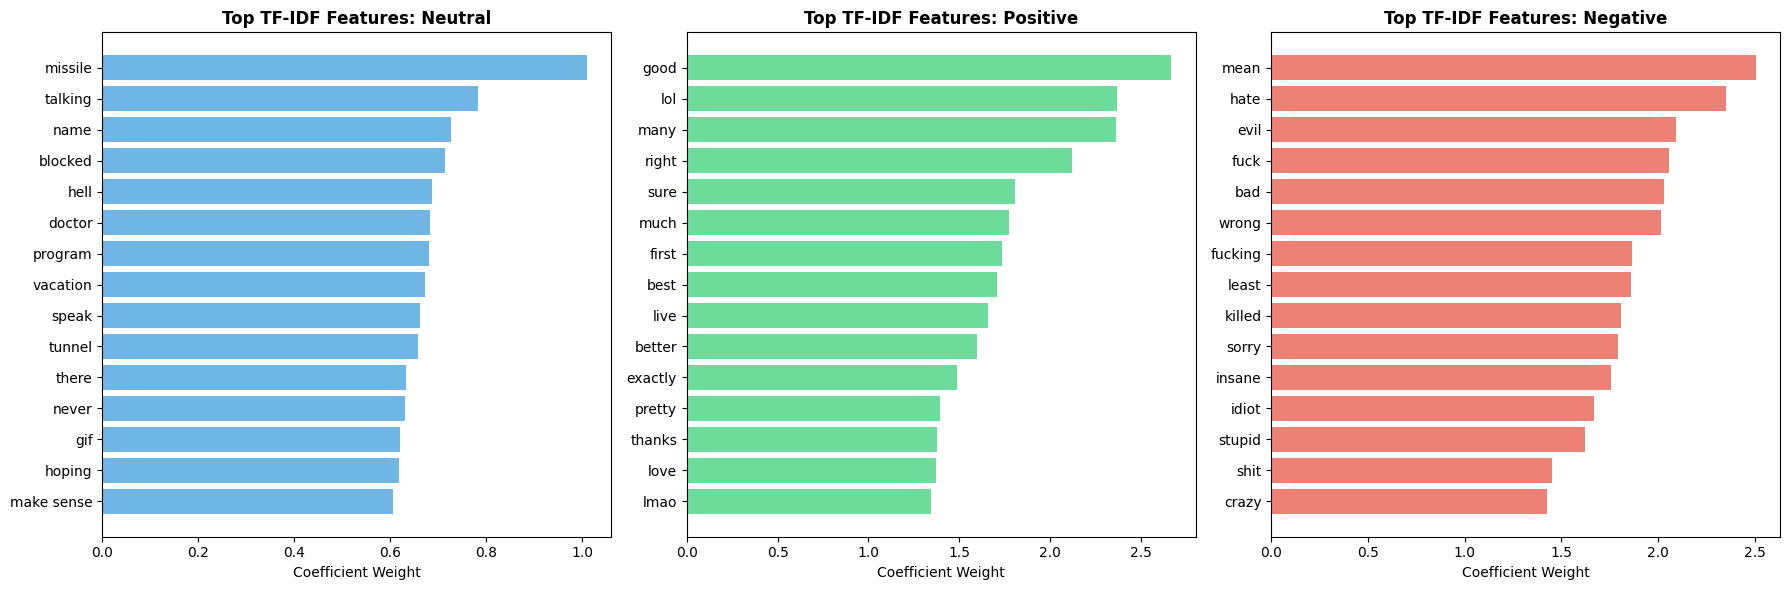

In [28]:
# ============================================================
# 11.2 TF-IDF Top Features per Class (Baseline)
# ============================================================
feature_names = np.array(tfidf.get_feature_names_out())

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
sentiment_names = ['Neutral', 'Positive', 'Negative']

for i, (ax, label_name) in enumerate(zip(axes, sentiment_names)):
    # Get coefficients for this class
    if len(baseline_model.coef_.shape) > 1:
        coefs = baseline_model.coef_[i]
    else:
        coefs = baseline_model.coef_[0]
    top_idx = coefs.argsort()[-15:]
    ax.barh(range(15), coefs[top_idx], color=colors[i], alpha=0.7)
    ax.set_yticks(range(15))
    ax.set_yticklabels(feature_names[top_idx])
    ax.set_title(f'Top TF-IDF Features: {label_name}', fontweight='bold')
    ax.set_xlabel('Coefficient Weight')

plt.tight_layout()
plt.savefig('tfidf_top_features.png', dpi=150, bbox_inches='tight')
plt.show()

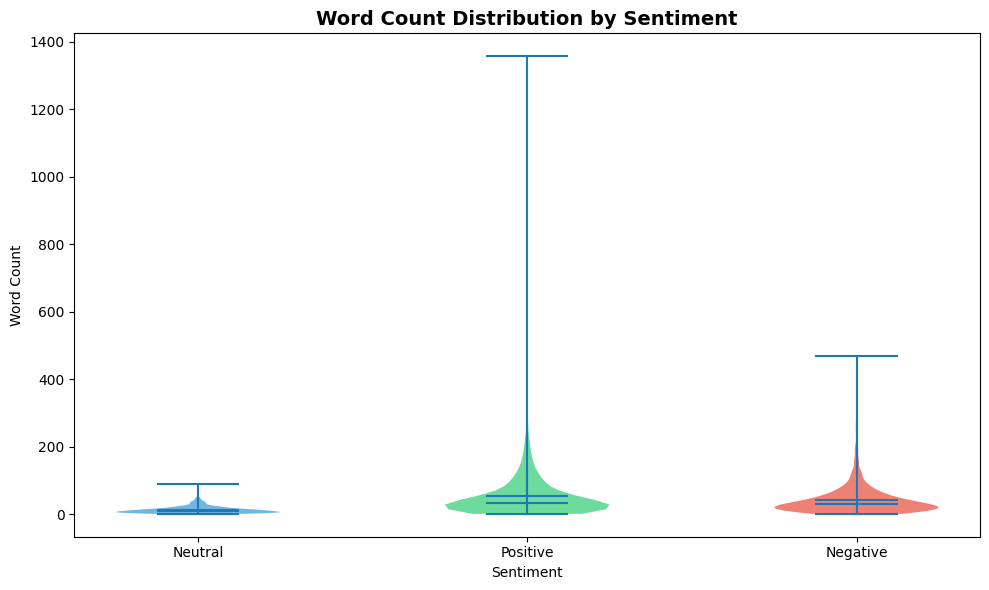

In [29]:
# ============================================================
# 11.3 Text Length vs Sentiment Violin Plot
# ============================================================
fig, ax = plt.subplots(figsize=(10, 6))
data_to_plot = [df[df['sentiment_label'] == i]['word_count'].values for i in [0, 1, 2]]
parts = ax.violinplot(data_to_plot, positions=[0, 1, 2], showmeans=True, showmedians=True)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(colors[i])
    pc.set_alpha(0.7)
ax.set_xticks([0, 1, 2])
ax.set_xticklabels(['Neutral', 'Positive', 'Negative'])
ax.set_title('Word Count Distribution by Sentiment', fontsize=14, fontweight='bold')
ax.set_xlabel('Sentiment')
ax.set_ylabel('Word Count')
plt.tight_layout()
plt.savefig('violin_word_count.png', dpi=150, bbox_inches='tight')
plt.show()

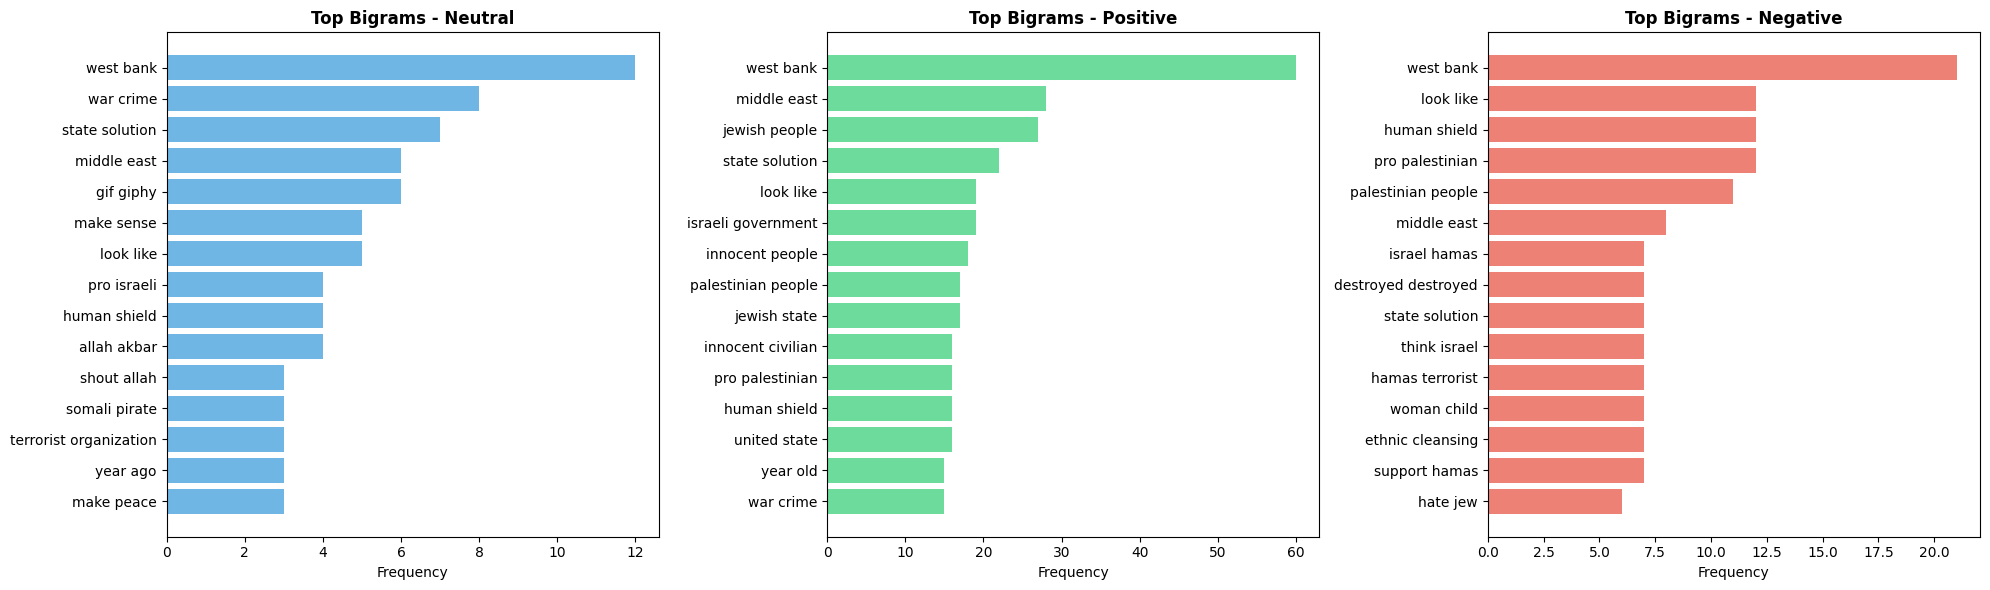

In [30]:
# ============================================================
# 11.4 N-gram Analysis
# ============================================================
from sklearn.feature_extraction.text import CountVectorizer

def plot_top_ngrams(corpus, n=2, top_k=15, title=''):
    vec = CountVectorizer(ngram_range=(n, n), stop_words='english', max_features=5000)
    ngrams = vec.fit_transform(corpus)
    counts = ngrams.sum(axis=0).A1
    words = vec.get_feature_names_out()
    top_idx = counts.argsort()[-top_k:]
    return words[top_idx], counts[top_idx]

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for i, (label, name) in enumerate(sentiments.items()):
    texts = df[df['sentiment_label'] == label]['processed_text']
    words, counts = plot_top_ngrams(texts, n=2, top_k=15)
    axes[i].barh(range(len(words)), counts, color=colors[i], alpha=0.7)
    axes[i].set_yticks(range(len(words)))
    axes[i].set_yticklabels(words)
    axes[i].set_title(f'Top Bigrams - {name}', fontweight='bold')
    axes[i].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('bigram_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

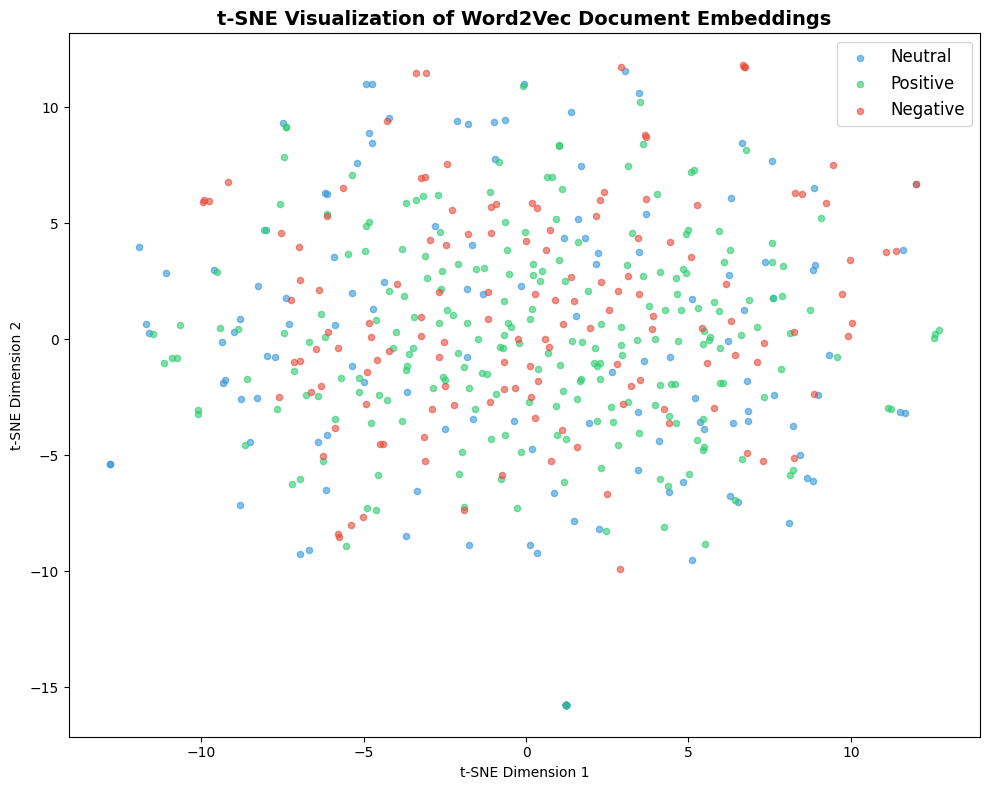

In [31]:
# ============================================================
# 11.5 Word Embedding Visualization (t-SNE)
# ============================================================
from sklearn.manifold import TSNE

# Use Word2Vec embeddings for visualization
sample_size = min(500, len(X_test_w2v))
np.random.seed(42)
sample_idx = np.random.choice(len(X_test_w2v), sample_size, replace=False)

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_test_w2v[sample_idx])

fig, ax = plt.subplots(figsize=(10, 8))
scatter_colors = ['#3498db', '#2ecc71', '#e74c3c']
for label, name in sentiments.items():
    mask = y_test.values[sample_idx] == label
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1],
              c=scatter_colors[label], label=name, alpha=0.6, s=20)

ax.set_title('t-SNE Visualization of Word2Vec Document Embeddings', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.set_xlabel('t-SNE Dimension 1')
ax.set_ylabel('t-SNE Dimension 2')
plt.tight_layout()
plt.savefig('tsne_w2v.png', dpi=150, bbox_inches='tight')
plt.show()

In [32]:
# ============================================================
# 11.6 Misclassification Analysis
# ============================================================
# Analyze where the best model makes mistakes
misclassified = X_test[y_test != y_pred_svm]  # using BERT+SVM as example
true_labels = y_test[y_test != y_pred_svm]
pred_labels = pd.Series(y_pred_svm, index=y_test.index)[y_test != y_pred_svm]

print(f"Total misclassified samples: {len(misclassified)}")
print(f"Misclassification rate: {len(misclassified)/len(y_test)*100:.1f}%")

print("Misclassification breakdown:")
for true_label in [0, 1, 2]:
    for pred_label in [0, 1, 2]:
        if true_label != pred_label:
            count = ((true_labels == true_label) & (pred_labels == pred_label)).sum()
            if count > 0:
                print(f"  {sentiments[true_label]} → {sentiments[pred_label]}: {count} samples")

print("Sample misclassified texts:")
for idx in misclassified.index[:5]:
    print(f"  Text: {X_test[idx][:80]}...")
    print(f"  True: {sentiments[y_test[idx]]}, Predicted: {sentiments[y_pred_svm[list(y_test.index).index(idx)]]}")
    print()

Total misclassified samples: 255
Misclassification rate: 41.4%
Misclassification breakdown:
  Neutral → Positive: 29 samples
  Neutral → Negative: 27 samples
  Positive → Neutral: 45 samples
  Positive → Negative: 75 samples
  Negative → Neutral: 22 samples
  Negative → Positive: 57 samples
Sample misclassified texts:
  Text: beirut really recovered fertilizer firework mishap yet...
  True: Positive, Predicted: Neutral

  Text: kick mean act...
  True: Negative, Predicted: Neutral

  Text: scare god almighty mina shaitaan nirajeem arrogance man...
  True: Neutral, Predicted: Negative

  Text: many westerner believe faith lead secretly support muslim terrorist group moroni...
  True: Positive, Predicted: Negative

  Text: fatah party practically sold west bank made many concession weird way ironic mon...
  True: Negative, Predicted: Positive



---
## 12. Summary & Key Findings

### Key Findings:
1. **Data Characteristics**: The dataset contains 3,125 Reddit comments with 3-class sentiment labels. Class imbalance exists with Positive (44.5%), Neutral (28.5%), and Negative (27.0%).

2. **Baseline Performance**: Logistic Regression with TF-IDF provides a solid baseline. The TF-IDF representation captures important unigram and bigram features.

3. **Embedding Comparison**:
   - BERT embeddings generally outperform Word2Vec and GloVe for this task, as they capture contextual semantics
   - Word2Vec/GloVe provide reasonable performance with faster computation

4. **Best Models**: BERT-based models (especially BERT + SVM and BERT + Ensemble) tend to perform best, leveraging deep contextual understanding.

5. **Refinement Impact**:
   - Hyperparameter tuning improves baseline performance
   - SMOTE helps address class imbalance
   - Ensemble methods combine strengths of multiple classifiers

6. **Challenges**: Short/ambiguous texts and neutral class remain difficult to classify accurately across all models.

### Recommendations:
- For production: BERT + SVM or Ensemble model provides the best balance of performance and reliability
- For speed: Word2Vec + XGBoost offers good performance with lower computational cost
- Further improvement: Fine-tuning BERT end-to-end could yield additional gains
